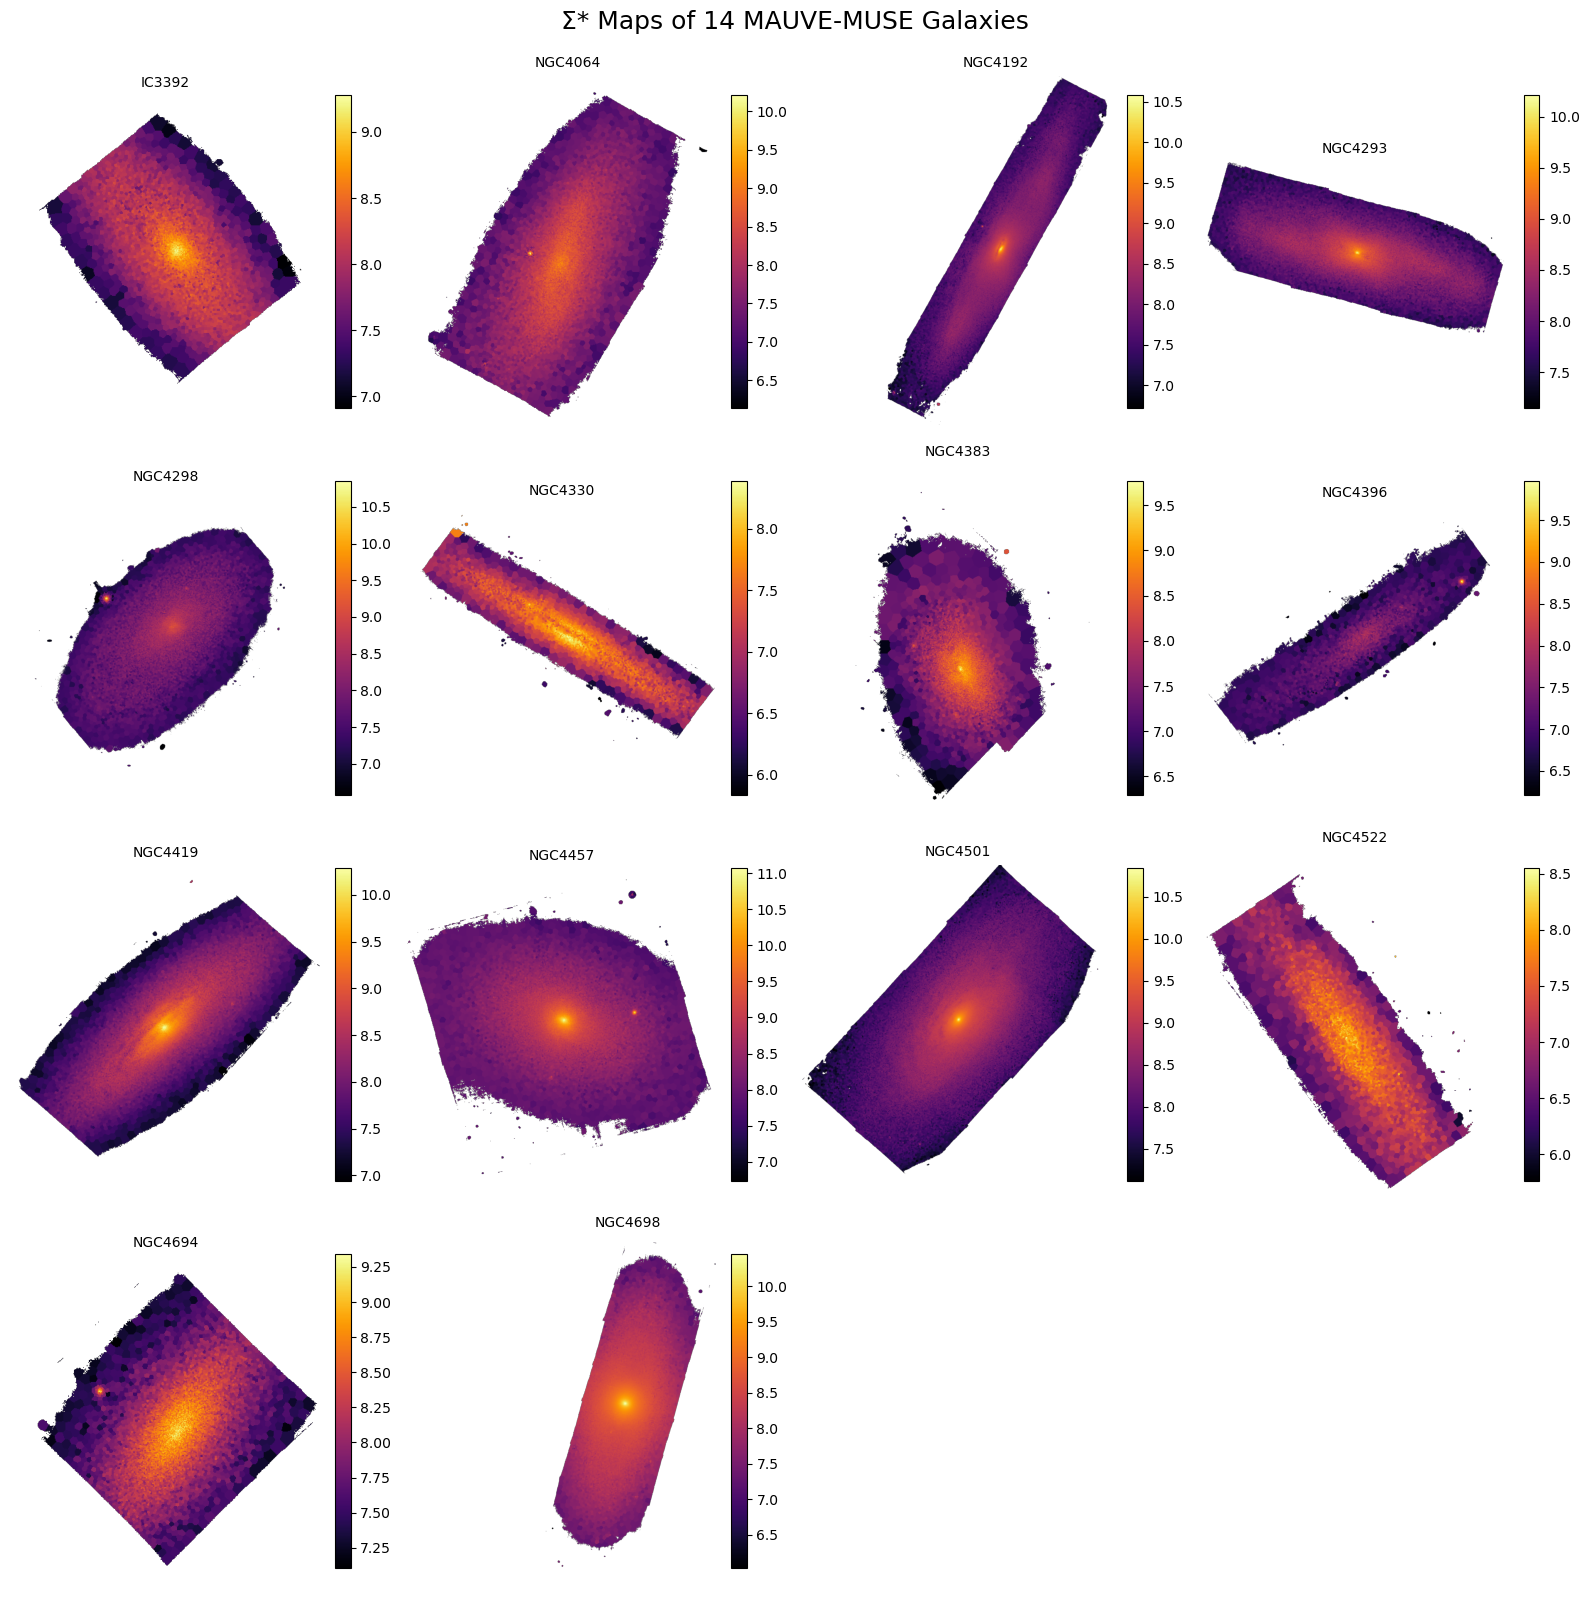

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from astropy.io import fits

# ------------------------------------------------------------------
# 0.  List galaxies
# ------------------------------------------------------------------
muse_path = Path('/Users/Igniz/Desktop/ICRAR/extended')
bin_maps = sorted(muse_path.glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bin_maps]        # auto-detect

# ------------------------------------------------------------------
# 1.  Helper: read Σ* map
# ------------------------------------------------------------------
def load_sigma_star(gal):
    with fits.open(muse_path / f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    return sigM

# ------------------------------------------------------------------
# 2.  Create 4×4 grid showing Σ* maps
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, gal in enumerate(galaxies[:16]):  # Use up to 16 galaxies for 4×4 grid
    sigM = load_sigma_star(gal)
    
    im = axes[i].imshow(sigM, origin='lower', cmap='inferno')
    axes[i].set_title(rf'{gal}', fontsize=10)
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Hide any unused subplots
for i in range(len(galaxies), 16):
    axes[i].axis('off')

fig.suptitle(r'Σ* Maps of 14 MAUVE-MUSE Galaxies', fontsize=18, y=0.995)
fig.tight_layout()
plt.show()


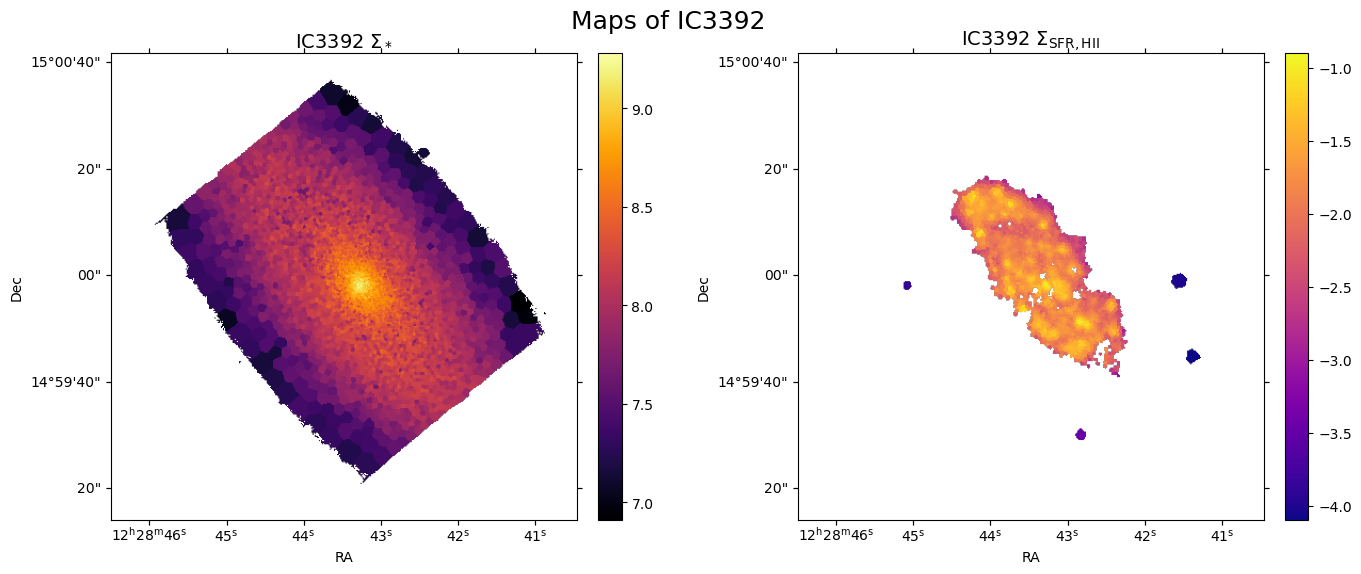

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

# ------------------------------------------------------------------
# 0.  List galaxies
# ------------------------------------------------------------------
muse_path = Path('/Users/Igniz/Desktop/ICRAR/extended')
bin_maps = sorted(muse_path.glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bin_maps]        # auto-detect

# Filter for IC3392
galaxies = [g for g in galaxies if g.lower() == 'ic3392']

# ------------------------------------------------------------------
# 1.  Helper: read maps with WCS
# ------------------------------------------------------------------
def load_sigma_star(gal):
    with fits.open(muse_path / f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h['LOGMASS_SURFACE_DENSITY'].header)
    return sigM, wcs

def load_sfr_hii(gal):
    with fits.open(muse_path / f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        wcs = WCS(h['LOGSFR_SURFACE_DENSITY_HII'].header)
    return sigSFR_HII, wcs

# ------------------------------------------------------------------
# 2.  Show Σ* and SFR maps for IC3392 with WCS
# ------------------------------------------------------------------
if galaxies:
    gal = galaxies[0]
    
    # Load data
    sigM, wcsM = load_sigma_star(gal)
    sigSFR, wcsSFR = load_sfr_hii(gal)
    
    fig = plt.figure(figsize=(14, 6))
    
    # Plot Σ*
    ax1 = fig.add_subplot(1, 2, 1, projection=wcsM)
    im1 = ax1.imshow(sigM, origin='lower', cmap='inferno')
    ax1.set_title(rf'{gal} $\Sigma_*$', fontsize=14)
    ax1.set_xlabel('RA')
    ax1.set_ylabel('Dec')
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    # Plot SFR HII
    ax2 = fig.add_subplot(1, 2, 2, projection=wcsSFR)
    im2 = ax2.imshow(sigSFR, origin='lower', cmap='plasma')
    ax2.set_title(rf'{gal} $\Sigma_{{\rm SFR, HII}}$', fontsize=14)
    ax2.set_xlabel('RA')
    ax2.set_ylabel('Dec')
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    fig.suptitle(rf'Maps of {gal}', fontsize=18, y=0.95)
    fig.tight_layout()
    plt.show()
else:
    print("Galaxy IC3392 not found in the data path.")

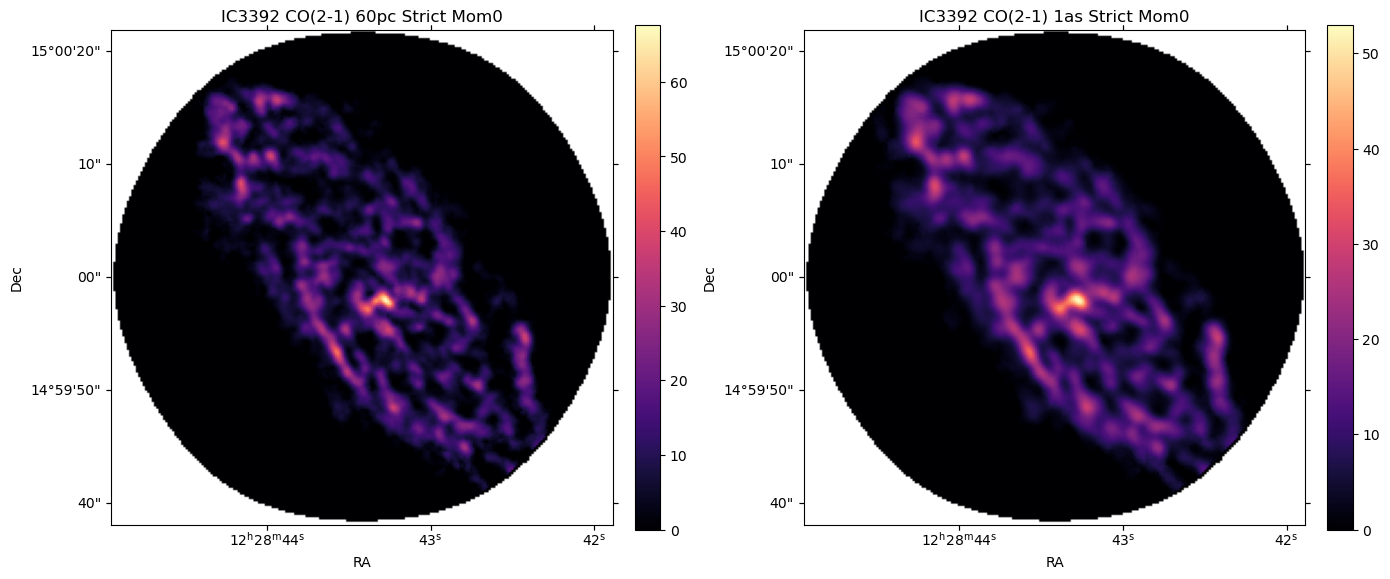

In [3]:
# ------------------------------------------------------------------
# 3.  Show ALMA CO(2-1) Moment 0 Maps (60pc & 1as) with WCS
# ------------------------------------------------------------------
alma_path = Path('/Users/Igniz/Desktop/ICRAR/CO/products_v0.3/ic3392')

# Define filenames
file_strict = alma_path / 'ic3392_12m+7m+tp_co21_60pc_strict_mom0.fits'
file_1as = alma_path / 'ic3392_12m+7m+tp_co21_1as_strict_mom0.fits'

def load_alma_mom0(filepath):
    with fits.open(filepath) as h:
        data = h[0].data
        header = h[0].header
        wcs = WCS(header)
        
        # Squeeze to remove degenerate dimensions (e.g. Stokes, Freq) if present
        if data.ndim > 2:
            data = data.squeeze()
            # Extract the celestial (spatial) part of the WCS if dimensions were squeezed
            wcs = wcs.celestial
            
    return data, wcs

# Load the maps
try:
    mom0_strict, wcs_strict = load_alma_mom0(file_strict)
    mom0_1as, wcs_1as = load_alma_mom0(file_1as)

    # Plot
    fig = plt.figure(figsize=(14, 6))

    # 60pc Strict
    ax1 = fig.add_subplot(1, 2, 1, projection=wcs_strict)
    im1 = ax1.imshow(mom0_strict, origin='lower', cmap='magma')
    ax1.set_title('IC3392 CO(2-1) 60pc Strict Mom0')
    ax1.set_xlabel('RA')
    ax1.set_ylabel('Dec')
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    # 1as Strict
    ax2 = fig.add_subplot(1, 2, 2, projection=wcs_1as)
    im2 = ax2.imshow(mom0_1as, origin='lower', cmap='magma')
    ax2.set_title('IC3392 CO(2-1) 1as Strict Mom0')
    ax2.set_xlabel('RA')
    ax2.set_ylabel('Dec')
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

In [4]:
from astropy.wcs.utils import proj_plane_pixel_scales

# ------------------------------------------------------------------
# 4.  Check WCS and Pixel Scales
# ------------------------------------------------------------------

def analyze_wcs(filepath, ext_name=None, label="Data"):
    """
    Analyzes and prints WCS information for a given FITS file.
    Calculates pixel scale from image extent.
    """
    if not filepath.exists():
        print(f"File not found: {filepath}")
        return

    with fits.open(filepath) as h:
        # Determine extension
        if ext_name:
            header = h[ext_name].header
            data = h[ext_name].data
        else:
            header = h[0].header
            data = h[0].data
            if data.ndim > 2:
                data = data.squeeze()
        
        # Parse WCS
        w = WCS(header).celestial
        
        # Image dimensions
        ny, nx = data.shape
        
        # Center coordinate
        cx, cy = nx / 2, ny / 2
        center = w.pixel_to_world(cx, cy)
        
        # Get corners to calculate extent (using 0 and nx/ny to span the full dimension)
        # Note: In astropy WCS, integer coordinates are pixel centers. 
        # Spanning from 0 to nx covers nx pixels distance.
        corners = w.pixel_to_world([0, nx, nx, 0], [0, 0, ny, ny])
        ra_vals = [c.ra.deg for c in corners]
        dec_vals = [c.dec.deg for c in corners]
        
        ra_min, ra_max = min(ra_vals), max(ra_vals)
        dec_min, dec_max = min(dec_vals), max(dec_vals)
        
        # Calculate pixel scale from extent (User request)
        # Note: RA needs cos(dec) correction for angular size
        dec_center_rad = np.deg2rad(center.dec.deg)
        ra_extent_deg = (ra_max - ra_min) * np.cos(dec_center_rad)
        dec_extent_deg = dec_max - dec_min
        
        pix_scale_ra_arcsec = (ra_extent_deg / nx) * 3600
        pix_scale_dec_arcsec = (dec_extent_deg / ny) * 3600
        avg_pix_scale = (pix_scale_ra_arcsec + pix_scale_dec_arcsec) / 2
        
        # WCS derived pixel scale (for reference)
        wcs_scales = proj_plane_pixel_scales(w)
        wcs_pix_scale = np.mean(wcs_scales) * 3600
        
        print(f"=== {label} ===")
        print(f"File: {filepath.name}")
        print(f"Shape: {data.shape} (ny, nx)")
        print(f"Center: {center.to_string('hmsdms')}")
        print(f"RA Range:  {ra_min:.5f} ... {ra_max:.5f} deg")
        print(f"Dec Range: {dec_min:.5f} ... {dec_max:.5f} deg")
        print(f"Extent (approx): {ra_extent_deg*3600:.1f} x {dec_extent_deg*3600:.1f} arcsec")
        print(f"Calculated Pixel Scale: {avg_pix_scale:.4f} arcsec/pix (RA: {pix_scale_ra_arcsec:.4f}, Dec: {pix_scale_dec_arcsec:.4f})")
        print(f"Header WCS Pixel Scale: {wcs_pix_scale:.4f} arcsec/pix")
        print("-" * 30)

# Define files to check
file_muse = muse_path / 'ic3392_SPATIAL_BINNING_maps_extended.fits'
file_alma = alma_path / 'ic3392_12m+7m+tp_co21_60pc_strict_mom0.fits'

analyze_wcs(file_muse, ext_name='LOGMASS_SURFACE_DENSITY', label="MUSE (Sigma_*)")
analyze_wcs(file_alma, ext_name=None, label="ALMA (60pc Strict)")

# ------------------------------------------------------------------
# 5.  Check WCS and Pixel Scales for other resolutions
# ------------------------------------------------------------------

files_to_analyze = [
    "ic3392_12m+7m+tp_co21_1as_strict_mom0.fits",
    "ic3392_12m+7m+tp_co21_90pc_strict_mom0.fits",
    "ic3392_12m+7m+tp_co21_120pc_strict_mom0.fits",
    "ic3392_12m+7m+tp_co21_500pc_strict_mom0.fits"
]

for fname in files_to_analyze:
    # Extract label from filename for display
    try:
        parts = fname.split('_')
        res = parts[3]   # e.g. 1as, 90pc
        mask = parts[4]  # e.g. strict
        label = f"ALMA ({res} {mask})"
    except IndexError:
        label = f"ALMA ({fname})"

    analyze_wcs(alma_path / fname, ext_name=None, label=label)

=== MUSE (Sigma_*) ===
File: ic3392_SPATIAL_BINNING_maps_extended.fits
Shape: (438, 437) (ny, nx)
Center: 12h28m43.47055063s +14d59m58.06037329s
RA Range:  187.16856 ... 187.19370 deg
Dec Range: 14.98729 ... 15.01163 deg
Extent (approx): 87.4 x 87.6 arcsec
Calculated Pixel Scale: 0.2000 arcsec/pix (RA: 0.2000, Dec: 0.2000)
Header WCS Pixel Scale: 0.2000 arcsec/pix
------------------------------
=== ALMA (60pc Strict) ===
File: ic3392_12m+7m+tp_co21_60pc_strict_mom0.fits
Shape: (219, 222) (ny, nx)
Center: 12h28m43.41154907s +15d00m00.12400001s
RA Range:  187.17450 ... 187.18727 deg
Dec Range: 14.99395 ... 15.00612 deg
Extent (approx): 44.4 x 43.8 arcsec
Calculated Pixel Scale: 0.2000 arcsec/pix (RA: 0.2000, Dec: 0.2000)
Header WCS Pixel Scale: 0.2000 arcsec/pix
------------------------------
=== ALMA (1as strict) ===
File: ic3392_12m+7m+tp_co21_1as_strict_mom0.fits
Shape: (219, 222) (ny, nx)
Center: 12h28m43.41154907s +15d00m00.12400001s
RA Range:  187.17450 ... 187.18727 deg
Dec Range:

Reprojecting ALMA 60pc to MUSE grid using reproject_adaptive...


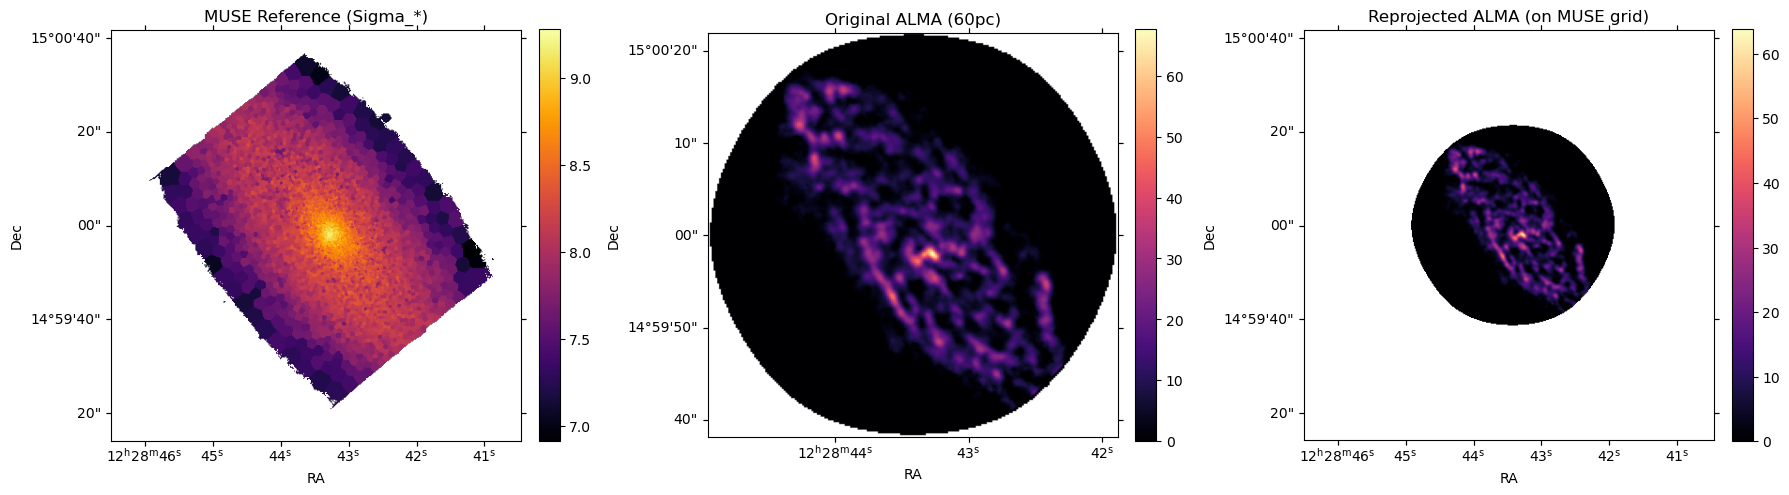

In [5]:
from reproject import reproject_adaptive

# ------------------------------------------------------------------
# 6.  Reproject ALMA to MUSE Grid (Adaptive)
# ------------------------------------------------------------------

# Define file paths
file_muse = muse_path / 'ic3392_SPATIAL_BINNING_maps_extended.fits'
file_alma_60pc = alma_path / 'ic3392_12m+7m+tp_co21_60pc_strict_mom0.fits'

# Load MUSE (Target) WCS and Shape
with fits.open(file_muse) as h:
    header_muse = h['LOGMASS_SURFACE_DENSITY'].header
    data_muse = h['LOGMASS_SURFACE_DENSITY'].data
    wcs_muse = WCS(header_muse)
    shape_muse = data_muse.shape

# Load ALMA (Source) Data and WCS
with fits.open(file_alma_60pc) as h:
    data_alma = h[0].data
    header_alma = h[0].header
    wcs_alma = WCS(header_alma).celestial
    if data_alma.ndim > 2:
        data_alma = data_alma.squeeze()

# Reproject
print("Reprojecting ALMA 60pc to MUSE grid using reproject_adaptive...")
# conserve_flux=True is used as requested. 
# Note: This scales values by the ratio of pixel areas if units are flux/pixel.
array_alma_reproj, footprint = reproject_adaptive(
    (data_alma, wcs_alma),
    wcs_muse,
    shape_out=shape_muse,
    conserve_flux=True
)

# Set points not in ALMA to NaN
array_alma_reproj[footprint == 0] = np.nan

# Plot results
fig = plt.figure(figsize=(18, 6))

# 1. MUSE Reference
ax1 = fig.add_subplot(1, 3, 1, projection=wcs_muse)
im1 = ax1.imshow(data_muse, origin='lower', cmap='inferno')
ax1.set_title('MUSE Reference (Sigma_*)')
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 2. Original ALMA
ax2 = fig.add_subplot(1, 3, 2, projection=wcs_alma)
im2 = ax2.imshow(data_alma, origin='lower', cmap='magma')
ax2.set_title('Original ALMA (60pc)')
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 3. Reprojected ALMA
ax3 = fig.add_subplot(1, 3, 3, projection=wcs_muse)
im3 = ax3.imshow(array_alma_reproj, origin='lower', cmap='magma')
ax3.set_title('Reprojected ALMA (on MUSE grid)')
ax3.set_xlabel('RA')
ax3.set_ylabel('Dec')
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Reprojecting MUSE (Sigma_*) to ALMA 60pc grid using reproject_adaptive...


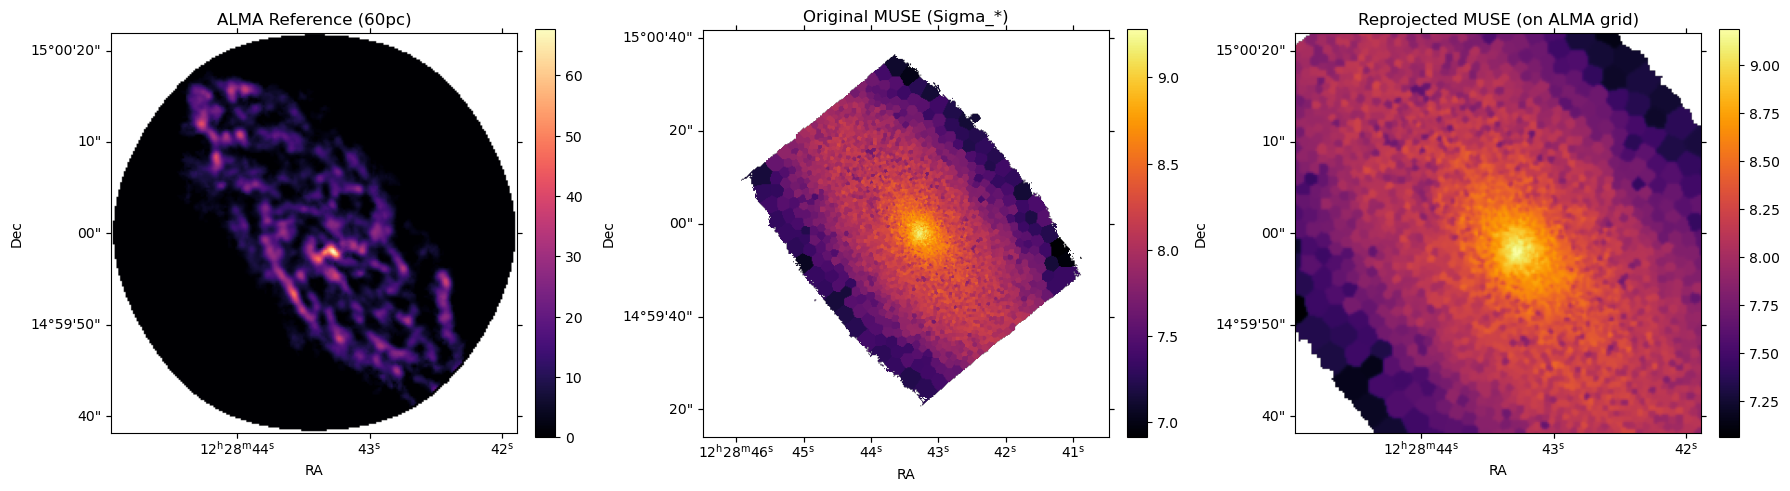

In [6]:
from reproject import reproject_adaptive

# ------------------------------------------------------------------
# 6.  Reproject MUSE to ALMA Grid (Adaptive)
# ------------------------------------------------------------------

# Define file paths
file_muse = muse_path / 'ic3392_SPATIAL_BINNING_maps_extended.fits'
file_alma_60pc = alma_path / 'ic3392_12m+7m+tp_co21_60pc_strict_mom0.fits'

# Load ALMA (Target) WCS and Shape
with fits.open(file_alma_60pc) as h:
    data_alma = h[0].data
    header_alma = h[0].header
    wcs_alma = WCS(header_alma).celestial
    if data_alma.ndim > 2:
        data_alma = data_alma.squeeze()
    shape_alma = data_alma.shape

# Load MUSE (Source) Data and WCS
with fits.open(file_muse) as h:
    header_muse = h['LOGMASS_SURFACE_DENSITY'].header
    data_muse = h['LOGMASS_SURFACE_DENSITY'].data
    wcs_muse = WCS(header_muse)

# Reproject
print("Reprojecting MUSE (Sigma_*) to ALMA 60pc grid using reproject_adaptive...")
# conserve_flux=True is used as requested. 
array_muse_reproj, footprint = reproject_adaptive(
    (data_muse, wcs_muse),
    wcs_alma,
    shape_out=shape_alma,
    conserve_flux=True
)

# Set points not in MUSE to NaN
array_muse_reproj[footprint == 0] = np.nan

# Plot results
fig = plt.figure(figsize=(18, 6))

# 1. ALMA Reference
ax1 = fig.add_subplot(1, 3, 1, projection=wcs_alma)
im1 = ax1.imshow(data_alma, origin='lower', cmap='magma')
ax1.set_title('ALMA Reference (60pc)')
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 2. Original MUSE
ax2 = fig.add_subplot(1, 3, 2, projection=wcs_muse)
im2 = ax2.imshow(data_muse, origin='lower', cmap='inferno')
ax2.set_title('Original MUSE (Sigma_*)')
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 3. Reprojected MUSE
ax3 = fig.add_subplot(1, 3, 3, projection=wcs_alma)
im3 = ax3.imshow(array_muse_reproj, origin='lower', cmap='inferno')
ax3.set_title('Reprojected MUSE (on ALMA grid)')
ax3.set_xlabel('RA')
ax3.set_ylabel('Dec')
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Reprojecting MUSE H-alpha Flux to ALMA 60pc grid using reproject_adaptive...


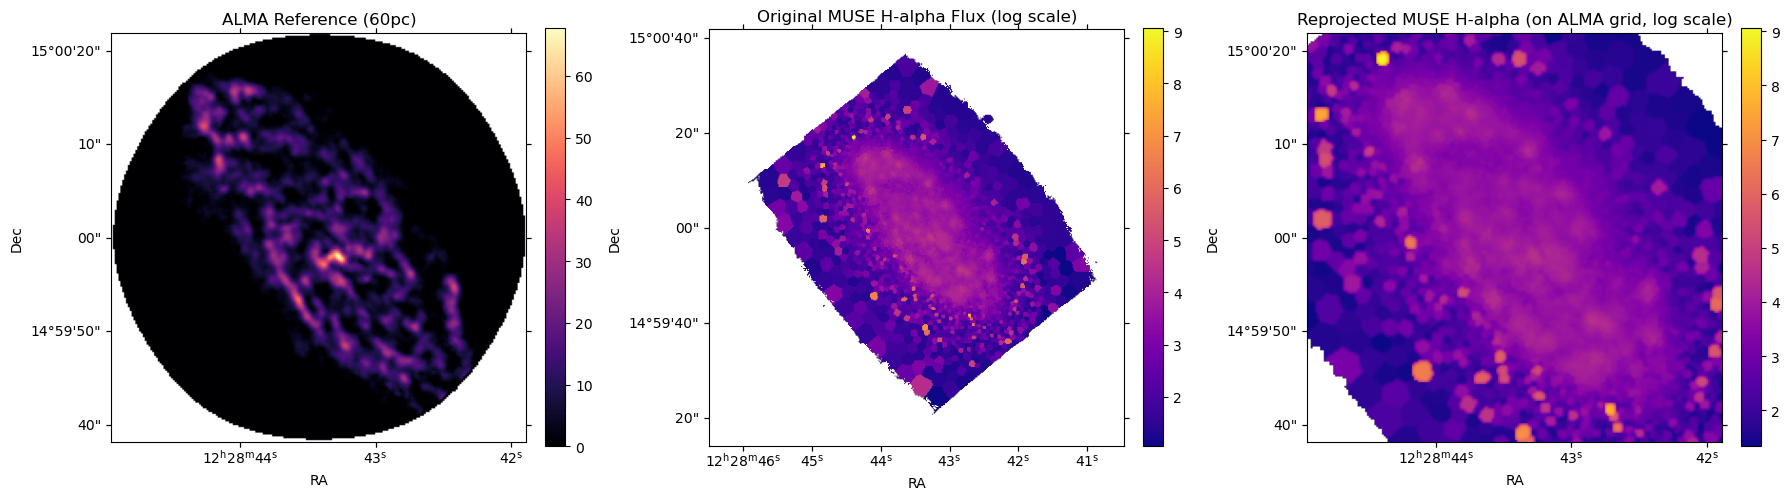

In [7]:
# ------------------------------------------------------------------
# 7.  Reproject MUSE H-alpha Flux to ALMA Grid
# ------------------------------------------------------------------

# Define file paths
file_muse_gas = muse_path / 'ic3392_gas_BIN_maps_extended.fits'
file_alma_60pc = alma_path / 'ic3392_12m+7m+tp_co21_60pc_strict_mom0.fits'

# Load ALMA (Target) WCS and Shape
with fits.open(file_alma_60pc) as h:
    data_alma = h[0].data
    header_alma = h[0].header
    wcs_alma = WCS(header_alma).celestial
    if data_alma.ndim > 2:
        data_alma = data_alma.squeeze()
    shape_alma = data_alma.shape

# Load MUSE H-alpha (Source) Data and WCS
with fits.open(file_muse_gas) as h:
    # Using extension HA6562_FLUX_CORR as requested
    header_muse_ha = h['HA6562_FLUX_CORR'].header
    data_muse_ha = h['HA6562_FLUX_CORR'].data
    wcs_muse_ha = WCS(header_muse_ha)

# Reproject
print("Reprojecting MUSE H-alpha Flux to ALMA 60pc grid using reproject_adaptive...")
array_ha_reproj, footprint_ha = reproject_adaptive(
    (data_muse_ha, wcs_muse_ha),
    wcs_alma,
    shape_out=shape_alma,
    conserve_flux=True
)

# Set points not in MUSE to NaN
array_ha_reproj[footprint_ha == 0] = np.nan

# Plot results
fig = plt.figure(figsize=(18, 6))

# 1. ALMA Reference
ax1 = fig.add_subplot(1, 3, 1, projection=wcs_alma)
im1 = ax1.imshow(data_alma, origin='lower', cmap='magma')
ax1.set_title('ALMA Reference (60pc)')
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 2. Original MUSE H-alpha
ax2 = fig.add_subplot(1, 3, 2, projection=wcs_muse_ha)
im2 = ax2.imshow(np.log10(data_muse_ha), origin='lower', cmap='plasma')
ax2.set_title('Original MUSE H-alpha Flux (log scale)')
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 3. Reprojected MUSE H-alpha
ax3 = fig.add_subplot(1, 3, 3, projection=wcs_alma)
im3 = ax3.imshow(np.log10(array_ha_reproj), origin='lower', cmap='plasma')
ax3.set_title('Reprojected MUSE H-alpha (on ALMA grid, log scale)')
ax3.set_xlabel('RA')
ax3.set_ylabel('Dec')
fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()